# **Summary**
This notebooks is divided into three sections to figure out the best model for prediction.
### EDA
Analyze the training dataset and investigate the coorelations between features and targets. Then doing scaling and feature selection as the performance of not doing feature selection will be very poor.
### Model Selection
1. Simple Models and ensemble models using scikit-learn: Using the basic and ensemble models to make predictions after splitting the training set into train and test subset.
2. NN Models: Build a simple NN model to make binary classification with minimal hyperparameters to be fine tuned.
### Create final test-this-0.csv file
Using the NN model to make predictions as it has better accurancy compared with scikit learn models.

## Section 1: EDA
1. Class balance (0s VS 1s)
2. Relationships between features and targets

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [41]:
dataset_df = pd.read_csv("/content/train-io.csv", header=None)
print(dataset_df.shape)
print(dataset_df.head())
# Separate features and target
X = dataset_df.iloc[:, :-1]
y = dataset_df.iloc[:, -1]
print(X.shape)
print(y.shape)

(290000, 13)
         0         1         2         3         4         5          6   \
0 -0.885048  2.572319 -0.215574  2.690738  6.419367  4.048689   1.376865   
1 -2.034505  4.279334 -1.123356 -4.675577 -1.908106 -0.921286   0.345189   
2 -2.645468  6.912199  7.630215 -3.654877  3.340537 -1.882834  12.730138   
3  0.970622 -4.985594  0.823282  5.891279 -7.684365  2.960496   0.459008   
4  9.996307  8.465283 -1.760814 -4.887802  5.669225  1.033578   6.390984   

         7          8         9         10        11  12  
0 -1.643209   3.913443  0.676847  1.805306  2.745879   1  
1  5.770364 -11.374391 -2.602378  7.138221  1.224691   1  
2 -4.243306  -7.752884 -8.008086  1.578602 -3.756767   1  
3  0.125224   5.807754  4.396019  0.600143 -0.519867   1  
4  0.021575  -4.247571 -4.670709  2.207625  5.785162   0  
(290000, 12)
(290000,)


============ Features Statistics ===========
                  0              1              2              3   \
count  290000.000000  290000.000000  290000.000000  290000.000000   
mean       -0.017150      -0.003784       0.000258      -0.002836   
std         5.920395       5.069492       6.466352       6.549496   
min       -21.809518     -18.656530     -22.731224     -24.261090   
25%        -4.131469      -3.549337      -4.489031      -4.519485   
50%        -0.008861      -0.004114       0.010895      -0.000099   
75%         4.104256       3.537988       4.483561       4.518510   
max        22.263966      18.738181      25.091762      24.393706   

                  4              5              6              7   \
count  290000.000000  290000.000000  290000.000000  290000.000000   
mean        0.001953      -0.002483       0.003573       0.001407   
std         5.499119       3.896987       6.047689       4.677725   
min       -19.171091     -14.670069     -23.068996     -1

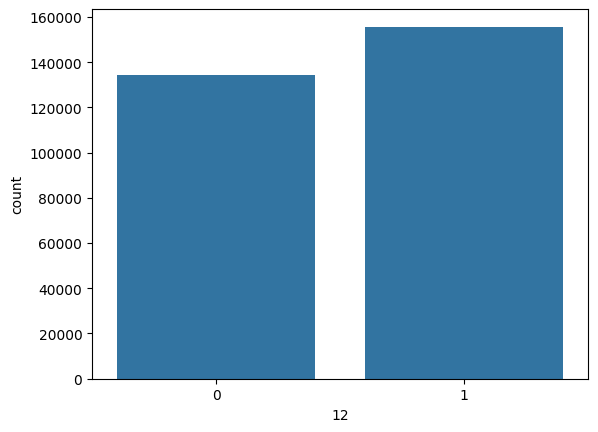

======= Coorelations: Heatmap for feature relationships =======


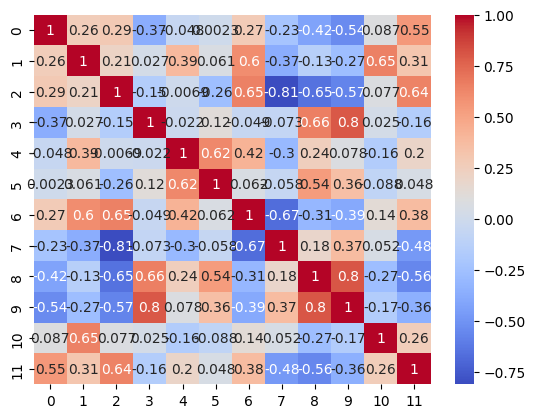

In [ ]:
print("============ Features Statistics ===========")
print(X.describe())

print("============== Class Statistics ============")
print(y.value_counts(normalize=True))

print("======= Coorelations: Heatmap for feature-feature relationships =======")
corr = X.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Identify features most correlated with target
target_coorelations = X.corrwith(y).sort_values(ascending=False)
print(target_coorelations)

8     0.001445
9     0.001254
5     0.001197
3     0.001042
4     0.000307
6     0.000146
2     0.000082
7    -0.000230
10   -0.001304
1    -0.001725
11   -0.002340
0    -0.002479
dtype: float64


## Section 2.1: Simple & Ensemble Models and Evaluation
Features have near-zero coorelation with the target, meaning the relationship is likely non-linear or complex --> Feature engineering
1. Decision Tree & Logistic Regression
2. Random Forest & Gradient Boosting


In [42]:
# Create polynomial features for capturing non-linearity
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
print(f"Polynomial features: {X_poly.shape[1]}")
feature_names = poly.get_feature_names_out(input_features=X.columns.astype(str))
X_poly = pd.DataFrame(X_poly, columns=feature_names)
poly_correlation = X_poly.corrwith(y).sort_values(ascending=False)
print(poly_correlation)
# Drop NA and select features above threshold
selected_features = poly_correlation.dropna()
selected_features = selected_features[abs(selected_features) > 0.01]
print(selected_features)
X_selected = X_poly[selected_features.index]

Polynomial features: 91


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


6 7     0.047488
2 7     0.046689
3 7     0.026560
8 10    0.024751
5 10    0.023318
          ...   
2^2    -0.046158
5^2    -0.050051
6^2    -0.055262
7^2    -0.057995
1            NaN
Length: 91, dtype: float64
6 7      0.047488
2 7      0.046689
3 7      0.026560
8 10     0.024751
5 10     0.023318
9 10     0.022818
7 11     0.021447
1 7      0.021377
2 8      0.020809
4 7      0.018444
2 9      0.017935
1 9      0.016893
5 7      0.015792
8 11     0.015074
6 9      0.013492
0 7      0.010392
6 10    -0.010640
1 2     -0.010665
3 5     -0.010790
4 11    -0.010882
2 10    -0.011402
0 4     -0.011619
1 11    -0.012123
7 9     -0.013183
2 3     -0.013981
10 11   -0.014659
3 8     -0.015445
6 11    -0.017107
0 1     -0.017420
0 11    -0.018185
0^2     -0.018602
3 6     -0.020070
4 8     -0.020761
3^2     -0.021506
8 9     -0.021542
9^2     -0.022126
1 4     -0.022234
2 11    -0.023253
1 10    -0.028106
5 9     -0.028322
4 6     -0.028978
10^2    -0.032349
11^2    -0.032932
8^2     -0.0

In [43]:
# Train-test split and feature scaling on original features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=32)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Build model
def build_model(model):
  model.fit(X_train, y_train)
  y_predict = model.predict(X_test)
  print("Accuracy:", accuracy_score(y_test, y_predict))
  print("F1 Score:", f1_score(y_test, y_predict))
  print("Precision:", precision_score(y_test, y_predict))
  conf_matrix = confusion_matrix(y_test, y_predict)
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
  plt.show()


========== Logistic Regression ==========


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.5766034482758621
F1 Score: 0.6524477404928033
Precision: 0.5830719417181018


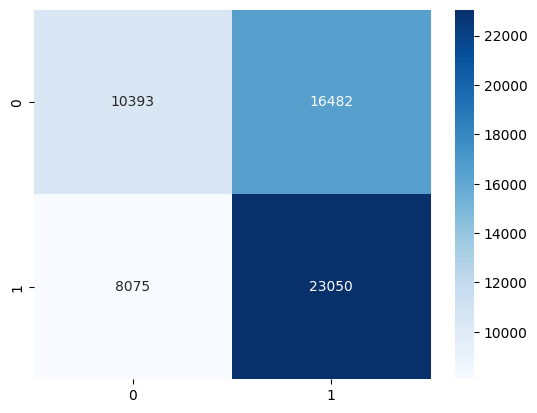

========== Decision Tree ==========
Accuracy: 0.516448275862069
F1 Score: 0.5490996784565917
Precision: 0.5495414320193082


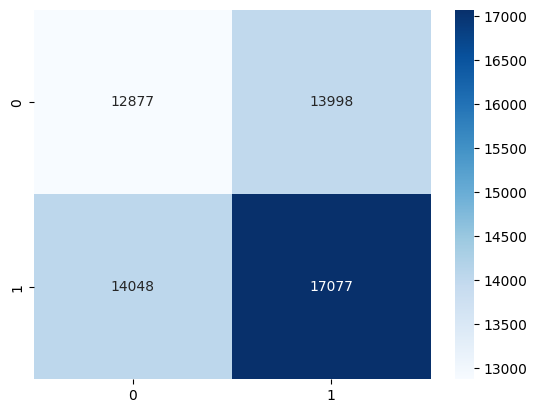

In [ ]:
simple_models = {
    "Logistic Regression": LogisticRegression(random_state=32),
    "Decision Tree": DecisionTreeClassifier(random_state=32),
}
for model_name, model in simple_models.items():
  print(f"========== {model_name} ==========")
  build_model(model)

========== Random Forest ==========
Accuracy: 0.5627241379310345
F1 Score: 0.6278284858979251
Precision: 0.5778342022095567


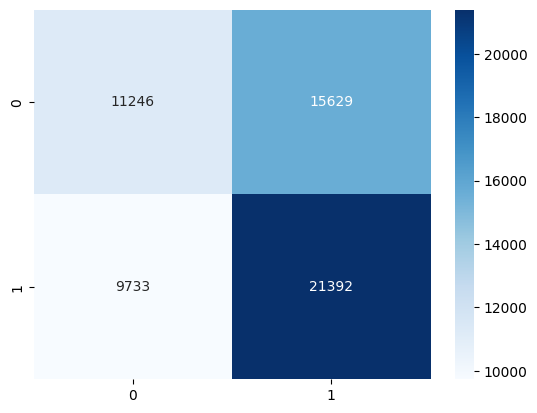

========== Gradient Boosting ==========
Accuracy: 0.5639827586206897
F1 Score: 0.6710117212400317
Precision: 0.5637897866386848


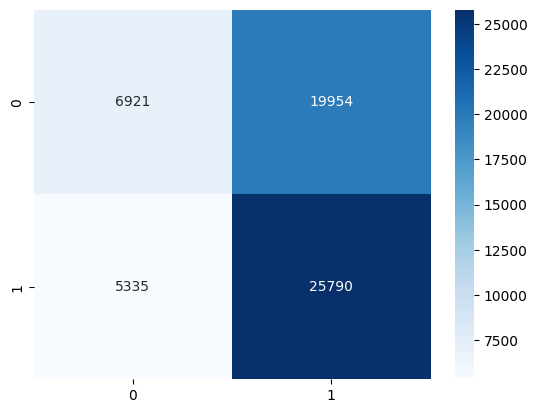

In [44]:
ensemble_models = {
    "Random Forest": RandomForestClassifier(random_state=32),
    "Gradient Boosting": GradientBoostingClassifier(random_state=32),
}

for model_name, model in ensemble_models.items():
  print(f"========== {model_name} ==========")
  build_model(model)

## Section 2.2: Neural Netowrks and Evaluation
Build NN to handle non-linearity and make predictions




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Build a simple nerual network model
nn_model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
optimizer = keras.optimizers.Adam(learning_rate=0.001)
nn_model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

# Callback for better training
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
]

# Train the model
history = nn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1813/1813 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step
Accuracy: 0.6480
F1-score: 0.6964
Precision: 0.6482


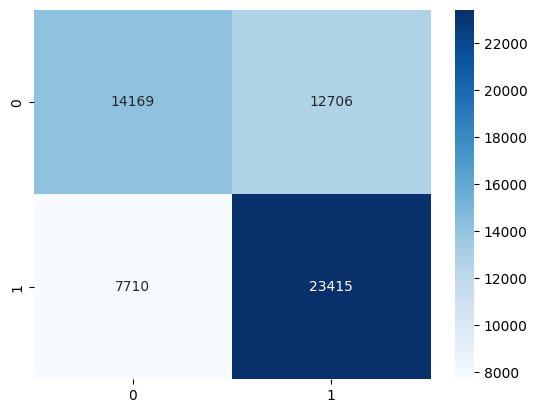

In [ ]:
# Evaluate the model
y_pred_prob = nn_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.show()


## Section 3: Generate test-this-o.csv

In [ ]:
# Load test data
test_df = pd.read_csv("/content/test-i.csv", header=None)
print(test_df.shape)
# Make prediction using NN models
X_test_scaled = scaler.transform(test_df)
y_pred_prob = nn_model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)
print(y_pred.shape)
print(f"Total predictions: {len(y_pred)}")
print(f"Class distribution:")
print(pd.Series(y_pred.flatten()).value_counts().sort_index())
# Save to .csv
pd.Series(y_pred.flatten()).to_csv("test-this-o.csv", index=False, header=False)


(10000, 12)
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
(10000, 1)
Total predictions: 10000
Class distribution:
0    3843
1    6157
Name: count, dtype: int64
